# Task 3

### 3.1 To execute the linear regression as you did in the previous task, you'll need to group the data by age groups to find the mean across all regions. Inspect the data to see that now you have way more age groups that in the previous task. Additionally, some fields need to be cleaned e.g., the “years” column need to be converted to an integer and the text that is not number has to be removed.

In [48]:
# Read the data
import pandas as pa
import numpy as np
data = open("inc_utf.csv").readlines()
# Prepare the data with a list and comprehension
cleaned_data = [ (int(region[:2]),int(age.replace(" years","").replace("+","")), float(income))
                for row in data[1:]
                 for _, region, age, income in [row.strip().split(",")]]
# Task 3.2
df = pa.DataFrame(cleaned_data, columns=["region", "age", "income"])
data_to_model = df.groupby("age")["income"].mean().to_frame().reset_index().sort_values(by=["age"], ascending=True).to_numpy()
rng = np.random.default_rng(42)
rng.shuffle(data_to_model)
train_set_size = int(len(data_to_model) * 0.8)
train_set, test_set = data_to_model[:train_set_size], data_to_model[train_set_size:]

age_train = train_set[:,0]
income_train = train_set[:,1]
X_train = np.column_stack((np.ones(len(age_train)), age_train))
theta_hat = np.linalg.inv(X_train.T.dot(X_train)).dot(X_train.T).dot(income_train)


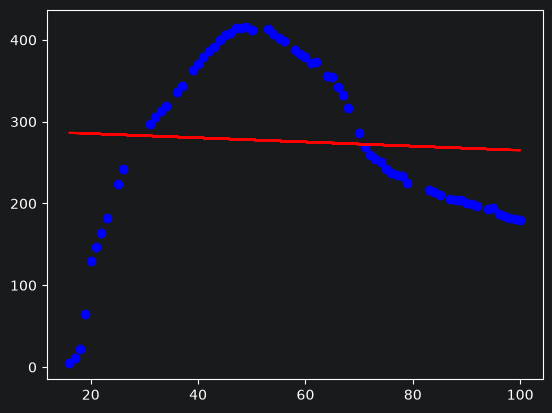

In [49]:
# Task 3.3
import matplotlib.pyplot as plt
plt.scatter(age_train, income_train, color="blue", label="Training data")
y_predicted = theta_hat.dot(X_train.T) # We can also do X_train.dot(theta_hat), this is due to the different number of columns in the np arrays
plt.plot(age_train, y_predicted, color="red", label="Regression line")

In [50]:
# Task 3.4
age_test = test_set[:,0]
income_test = test_set[:,1]
X_val = np.column_stack((np.ones(len(age_test)), age_test))
y_predicted_test = X_val.dot(theta_hat)
for real, pred in zip(income_test, y_predicted_test):
    print(f"Real: {real:.2f}, Predicted: {pred:.2f}")

Real: 258.23, Predicted: 283.63
Real: 206.06, Predicted: 268.57
Real: 392.87, Predicted: 275.97
Real: 354.17, Predicted: 280.82
Real: 327.88, Predicted: 281.59
Real: 412.33, Predicted: 277.51
Real: 219.44, Predicted: 270.10
Real: 364.36, Predicted: 274.44
Real: 271.53, Predicted: 283.38
Real: 307.17, Predicted: 272.91
Real: 291.07, Predicted: 282.87
Real: 282.83, Predicted: 283.12
Real: 214.73, Predicted: 269.59
Real: 410.41, Predicted: 277.25
Real: 217.51, Predicted: 269.85
Real: 196.46, Predicted: 266.78
Real: 202.08, Predicted: 284.40


In [51]:
# Task 3.5
mse = np.mean((income_test - y_predicted_test)**2)
print(f"MSE: {mse:.2f}")
print(f"RMSE: {np.sqrt(mse):.2f}")

MSE: 5362.04
RMSE: 73.23


### Task 3.6 and 4.1, 4.2
As previously the MSE is hard to talk about since we do not talk in terms of average_income squared units, and thus taking the square root we can see that the RMSE is almost three times higher than the previous model, 73,23 compared to 26.56, the plot in task 3.3 also shows that a linear regression is not very good at estimating the income based on age.

The curvature is much more visible in the graph with more age groups, and the predicted values are deviating more from the model function leading to a much higher MSE. The analysis could maybe be improved using a polynomial regression since the data is more complex than a straight line.




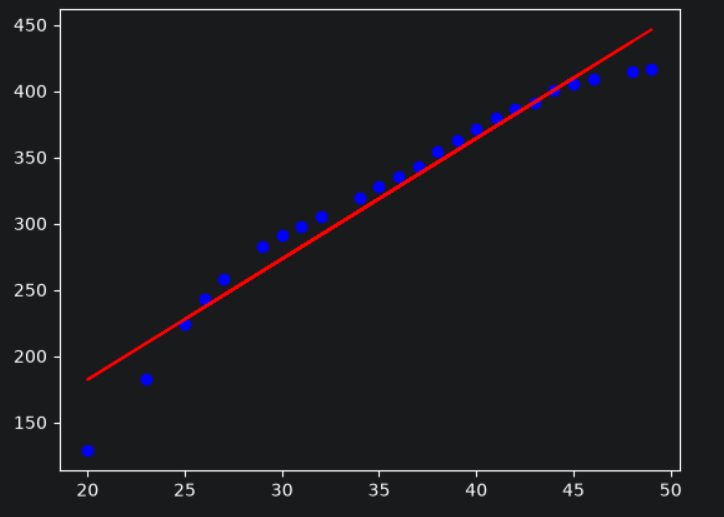
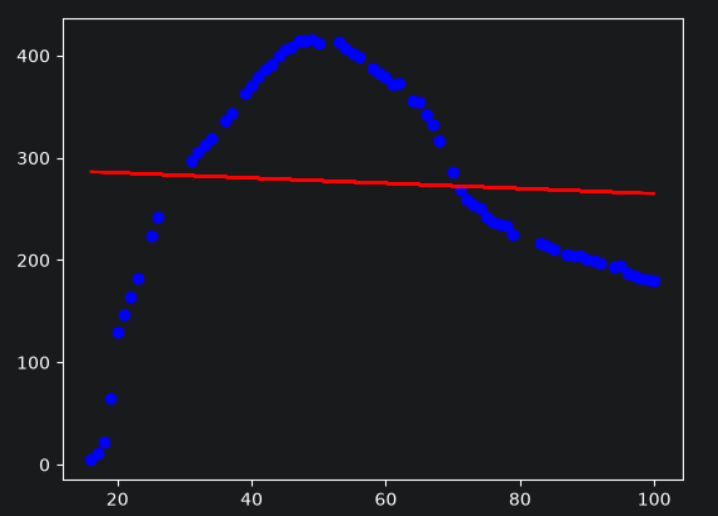

![image.png](Screenshot%202026-09-14%20234405.png)